# Daten speichern und laden

Oft ist es nützlich, Daten am Computer zu speichern um sie auch nach Programmende weiterverwenden zu können.


Um eine Datei zu öffnen, benutzt man den Befehl `open(path, mode)`
- `path`: der Pfad zur Datei 
    - relativ zum aktuellen Verzeichnis (z.B. 'data/example.txt'),
    - oder absolut (z.B. '/Users/michael/Repositories/EPROG_2025/data/example.txt')
- `mode`: der Modus, in dem die Datei geöffnet wird:
    - `'r'`: Lesen (read) - Standardmodus, wenn nicht angegeben
    - `'w'`: Schreiben (write) - überschreibt die Datei wenn sie existiert, oder erstellt eine neue Datei
    - `'a'`: Anhängen (append) - fügt Daten ans Ende der Datei wenn sie existiert, oder erstellt eine neue Datei
- `'b'`: Binärmodus (binary) - für nicht-text Dateien (z.B. Bilder, PDFs)
- `'t'`: Textmodus (text) - Standardmodus, wenn nicht angegeben

## Textdateien speichern & lesen
Der Rückgabewert von `open` ist ein Dateiobjekt, das Methoden zum Lesen und Schreiben von Daten bereitstellt.
- `f.write(data)`: schreibt den String `data` in die Datei
- `f.writelines(list_of_data)`: schreibt eine Liste von Strings in die Datei (ohne automatische Zeilenumbrüche)
- `f.read()`: liest den gesamten Inhalt der Datei als einen String
- `f.readlines()`: liest die Datei Zeile für Zeile und gibt eine Liste von Strings zurück
- `f.close()`: schließt die Datei (wichtig, um Daten zu speichern und Ressourcen freizugeben)

Die Dateiendung (z.B. `.txt`) ist nicht entscheidend, aber hilfreich um den Dateityp zu erkennen.


In [1]:
f = open('data/example.txt', 'w')
f.write('Hello, World!')
f.close()
f = open('data/example.txt', 'r')
content = f.read()
f.close()
print(content)

Hello, World!


## `with` Statement
Das `with` Statement ist eine elegante Möglichkeit, Dateien zu öffnen und sicherzustellen, dass sie korrekt geschlossen werden, auch wenn ein Fehler auftritt.
```python
with open(path, mode) as f:
    # Dateioperationen mit f
    ...
# Datei wird automatisch geschlossen, wenn der Block verlassen wird
```


In [55]:
with open('data/example.txt', 'w') as f:
    f.write('Hello, World!\n')
    f.write('This is a text file.\n')

with open('data/example.txt', 'r') as f:
    content = f.read()
    print(content)

with open('data/example.txt', 'a') as f:
    f.write('Appending a new line')

with open('data/example.txt', 'r') as f:
    content = f.read()
    print(content)

Hello, World!
This is a text file.

Hello, World!
This is a text file.
Appending a new line


Nach den beiden Schreibvorgängen oben sieht die Datei `data/example.txt` so aus:

<img src="illustrations/file.png" style="width: 600px;"/>

### Beispiel: Zeilennummern in eine Datei hinzufügen
Wir haben eine Textdatei `data/example.txt` mit folgendem Inhalt:

<img src="illustrations/poem.png" style="width: 600px;"/>





Wir wollen jede Zeile mit einer Zeilennummer versehen und das Ergebnis in eine neue Datei `data/numbered_poem.txt` schreiben.
- das `with` Statement kann mehrere Dateien gleichzeitig öffnen (getrennt durch Kommas)

In [56]:
with open('data/poem.txt', 'r') as infile, open('data/numbered_poem.txt', 'w') as outfile:
    line_list = infile.readlines()
    for i, line in enumerate(line_list):
        outfile.write(f"{i+1}: {line}")
        

Das ergebnis in `data/numbered_poem.txt` sieht dann so aus:

<img src="illustrations/poem_numbered.png" style="width: 600px;"/>

### Direkt durch das Dateiobjekt iterieren
Das Dateiobjekt ist selbst iterierbar, d.h., man kann direkt eine Schleife darüber laufen lassen, ohne vorher `readlines()` aufzurufen:

In [4]:
with open('data/poem.txt', 'r') as infile:
    for line in infile:
        print(line.strip())  # .strip() entfernt führende und nachfolgende Leerzeichen und Zeilenumbrüche

Das eilende Schiff, es kommt durch die Wogen
Wie Sturmwind geflogen.
Voll Jubel ertönt’s vom Mast und vom Kiele:
"Wir nahen dem Ziele."
Der Fährmann am Steuer spricht traurig und leise:
"Wir segeln im Kreise."


Damit kann man den obigen Code eleganter schreiben:

In [58]:
with open('data/poem.txt', 'r') as infile, open('data/numbered_poem.txt', 'w') as outfile:
    for i, line in enumerate(infile):
        outfile.write(f"{i+1}: {line}")

## CSV Dateien verarbeiten
CSV (Comma-Separated Values) Dateien sind ein gängiges Format zum Speichern tabellarischer Daten. Python bietet das eingebaute `csv` Modul, um CSV Dateien einfach zu lesen und zu schreiben.

```python
import csv
```

Das `csv` Modul stellt zwei Hauptklassen bereit:
- `csv.reader`: zum Lesen von CSV Dateien
- `csv.writer`: zum Schreiben von CSV Dateien

In [5]:
import csv
headings = ['Name', 'Age', 'City']
rows = [
    ['Alice', 30, 'New York'],
    ['Bob', 25, 'Los Angeles'],
    ['Charlie', 35, 'Chicago']
]
with open('data/people.csv', 'w') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(headings)
    writer.writerows(rows)
    

Die erstellte CSV Datei `data/people.csv` ist eine einfache Textdatei in der die Daten durch Kommas getrennt sind. Wenn man sie mit einem Tabellenkalkulationsprogramm (z.B. Excel) öffnet, wird sie als Tabelle dargestellt:

<img src="illustrations/csv_text.png" style="width: 400px;"/>
<img src="illustrations/csv.png" style="width: 400px;"/>

Um die Datei wieder einzulesen, verwenden wir `csv.reader`:

In [60]:
with open('data/people.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        print(row)

['Name', 'Age', 'City']
['Alice', '30', 'New York']
['Bob', '25', 'Los Angeles']
['Charlie', '35', 'Chicago']


Für die Weiterverarbeitung ist es oft praktischer, die Daten als Wörterbuch zu lesen, wobei die Spaltenüberschriften als Schlüssel verwendet werden. Dafür gibt es `csv.DictReader`:

In [61]:
with open('data/people.csv', 'r') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        for key, value in row.items():
            print(f"{key}: {value}", end=", ")
        print("")

Name: Alice, Age: 30, City: New York, 
Name: Bob, Age: 25, City: Los Angeles, 
Name: Charlie, Age: 35, City: Chicago, 


## JSON Dateien verarbeiten
JSON (JavaScript Object Notation) ist ein weit verbreitetes Format zum Austausch von Daten. Python bietet das eingebaute `json` Modul, um JSON Daten einfach zu lesen und zu schreiben. Eine JSON Datei ist eine Textdatei, die Daten in einer strukturierten, hierarchischen Form speichert.

JSON unterstützt Dictionaries (Objekte), Listen (Arrays), Strings, Zahlen, Booleans und `null` (None in Python).

Die Funktion `json.dump(data, file)` schreibt Python Datenstrukturen in eine JSON Datei, während `json.load(file)` JSON Daten aus einer Datei in Python Datenstrukturen lädt.
- Beim Schreiben von JSON Dateine kann man mit dem Parameter `indent` die Einrückung für eine bessere Lesbarkeit angeben.


In [62]:
import json

data = {
    "name": "Alice",
    "age": 30,
    "is_student": False,
    "scores": [95, 88, 76],
    "address": {"city": "New York", "zip": "10001"},
    "height": 1.68,
    "hobbies": None
}

my_list = [1, 2, 3, 4, 5]

with open('data/dict.json', 'w') as f1, open('data/list.json', 'w') as f2:
    json.dump(data, f1, indent=4)
    json.dump(my_list, f2)

with open('data/dict.json', 'r') as f1, open('data/list.json', 'r') as f2:
    loaded_dict = json.load(f1)
    loaded_list = json.load(f2)

print(loaded_dict['age'])
print(loaded_list)

30
[1, 2, 3, 4, 5]


Die JSON Datei `data/dict.json` sieht wie folgt aus:

<img src="illustrations/json.png" style="width: 400px;"/>

## Beispiel: Markov Ketten 
Eine Markov Kette ist ein mathematisches Modell um zufällige Prozesse zu beschreiben
- Der nächste Zustand hängt nur vom aktuellen Zustand ab (nicht von der Vorgeschichte)
- Der nächste Zustand wird durch den Zufall bestimmt
- Die Wahrscheinlichkeit von einem Zustand zum nächsten zu wechseln ist vorgegeben 

<img src="illustrations/markov.png" style="width: 200px;"/>



In [9]:
from random import random
transition_matrix = [[0.5, 0.5], [0.8, 0.2]]  
current_state = 0
num_steps = 50
for _ in range(num_steps):
    s = 'A' if current_state == 0 else 'B'
    print(s, end=' ')
    current_state = 0 if random() < transition_matrix[current_state][0] else 1

A A B A B B A B A A A B A B A A B A A B A A A B A B A A B A B A A B B A B A B A A A A A A A B A B B 

### Textgenerierung mit Markov-Ketten
Ein interessanteres Beispiel ist die Generierung von Text basierend auf einem gegebenen Textkorpus (z.B. "Alice im Wunderland").
- Aufgrund von zwei aufeinanderfolgenden Wörtern wird das nächste Wort ausgewählt
- Zuerst lesen wir den Text ein und speichern von allen aufeinanderfolgenden Wortpaaren die möglichen Folgewörter in einem `dict` ab
- Dann generieren wir neuen Text, indem wir mit einem zufälligen Wortpaar starten und immer wieder ein neues Wort basierend auf dem aktuellen Wortpaar auswählen

Im folgenden Code verwenden wir zwei neue Befehle
- `.isupper()`: überprüft, ob ein String nur aus Großbuchstaben besteht
- `textwrap.fill(text)`: formatiert einen langen String in mehrere Zeilen mit einer maximalen Breite (Standard 70 Zeichen)

Der Beispieltext "Alice im Wunderland" ist frei im Netz verfügbar (Project Gutenberg) und liegt in der Datei `data/alice.txt` vor.

<img src="illustrations/alice.png" style="width: 600px;"/>


In [14]:
from random import choice
import textwrap

# Class for generating text based on a Markov chain
class TextGenerator:
    def __init__(self, filename):
        self.possible_words = dict()
        
        # Build the dictionary of possible word transitions from the text file
        # (word1, word2) -> [list of possible next words]
        w1 = ''
        w2 = ''
        with open(filename, 'r') as f:
            for line in f:
                for word in line.split():
                    key = (w1, w2)
                    if key not in self.possible_words:
                        self.possible_words[key] = [word]
                    else:
                        self.possible_words[key].append(word)
                    w1, w2 = w2, word
                
    # Generate text of a given word count
    def generate_text(self, word_count=50):
        # Start with a random word pair where the first word has at least one letter and starts with a capital letter
        w1, w2 = choice([k for k in self.possible_words if len(k[0])>= 1 and k[0][0].isupper()])
        text = ""
        for _ in range(word_count):
            text += w1 + " "
            next_word = choice(self.possible_words[(w1, w2)]) # Randomly choose the next word based on the current pair
            w1, w2 = w2, next_word  # word2 becomes word1, next_word becomes word2
        return textwrap.fill(text)  # Format the text to fit within 70 characters per line (readability)
    
virtual_lewis_carroll = TextGenerator('data/alice.txt')
print(virtual_lewis_carroll.generate_text(100))


Alice asked in a great hurry; “and their names were Elsie, Lacie, and
Tillie; and they sat down again in a solemn tone, only changing the
order of the reeds—the rattling teacups would change to tinkling
sheep-bells, and the White Rabbit read:— “They told me he was in the
distance, screaming with passion. She had just begun to dream that she
ought not to make _one_ respectable person!” Soon her eye fell on a
crimson velvet cushion; and, last of all this time. “I want a clean
cup,” interrupted the Hatter: “it’s very interesting. I never heard of
‘Uglification,’” Alice


Der generierte Text sieht auf den ersten Blick nach üblichem Englisch aus, enthält aber viele sinnlose und unzusammenhängende Formulierungen.
- Die Markov Kette kann nur lokale Abhängigkeiten erfassen, was zu unzusammenhängenden Sätzen führt
- Für bessere Ergebnisse sind komplexere Modelle (z.B. neuronale Netze) erforderlich
- Large Language Models (LLMs) wie ChatGPT nutzen fortgeschrittene, aber im Grunde ähnliche, Prinzipien um Antworten zu generieren
    - Aus dem bereits generierten Text wird das wahrscheinlichste nächste Wort ausgewählt

Man kann auch das EIMA Skriptum laden (wenn man es vorher in reinen Text umgewandelt hat) und damit neue mathematisch klingende Texte generieren:

In [73]:
virtual_eima = TextGenerator('data/eima.txt')
print(textwrap.fill(virtual_eima.generate_text(100)))

RelationR und a∈A und b∈B verwendet man oft danach, einen Beweis so
klar wie möglich und so kurz wie möglich hinzuschreiben. Im
vorausgegangenen Beweis haben wir abschließend bewiesen, dass sich
jedesB ∈P+ k (A) genau in der Gruppe nebenP und Qnoch ein drittes
PferdRgibt, sodassP und R(als Pferde der Gruppe vonn+1 Pferden. SeiˆP
die Gruppe (SX,◦,IdX), die als symmetrische Gruppebzw. Permutations-
gruppe bezeichnet wird. Lemma 3.7. Manchmal kann/darf/muss man aber
auch nicht! Kommentar. Unsere Notation und Verwendung von Quantoren
sind immer von links nach rechts zu lesen und in diesem Fall sagen wir
auch, dassA eine n-elementige Menge ist und


Mit `matplotlib` kann man sehr einfach eine Heatmap der Übergangswahrscheinlichkeiten erstellen:
- Für jedes Wortpaar $(w_1,w_2)$ wählen wir ein mögliches nächstes Wortpaar $(w_2,w_3)$ aus
- Bassierend auf der Position der Paare in `possible_words.keys()` ordnen wir den Wortpaaren eine Nummer zu und  zeichnen den entsprechenden Punkt in der Heatmap
- Die Dichte der Punkte zeigt die Übergangswahrscheinlichkeiten zwischen den Wortpaaren
- Die dicke Line in der Diagonale entsteht, da jedes Wortpaar mit Nummer $i$ automatisch das nächste Wortpaar mit Nummer $i+1$ als möglichen Nachfolger hat
    - Die Line liegt also nicht exakt auf der Diagonalen, sondern leicht darüber

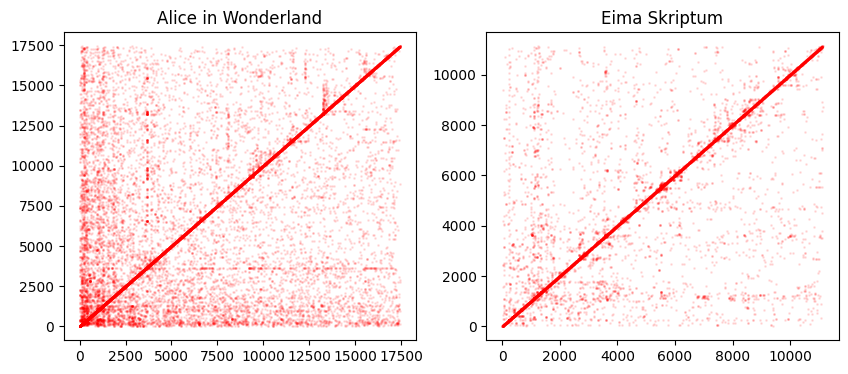

In [66]:
import matplotlib.pyplot as plt
def plot_heatmap(text_obj):
    keys = list(text_obj.possible_words.keys())
    N = len(keys)
    for i, key in enumerate(keys):
        next_words = text_obj.possible_words[key]
        for next_word in next_words:
            next_key = (key[1], next_word)
            try:
                k = keys.index(next_key)
                plt.plot(i,k, 'r.', alpha=0.1, markersize=2)
            except:
                continue
plt.subplots(1, 2, figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title('Alice in Wonderland')
plot_heatmap(virtual_lewis_carroll)
plt.subplot(1, 2, 2)
plt.title('Eima Skriptum')
plot_heatmap(virtual_eima)
plt.show()